In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from optimask import OptiMask
from optimask.utils import generate_mar, plot

In [2]:
[p.unlink() for p in Path('.').glob('*.png')]

[None, None, None, None, None, None, None]

In [3]:
DPI = 400

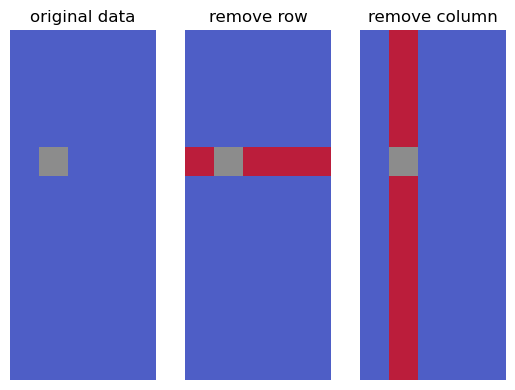

In [4]:
x = np.zeros((12, 5))
x[7, 1] = np.nan

plt.figure()
plt.subplot(1, 3, 1)
plot(x, show=False, title="original data")
plt.subplot(1, 3, 2)
plot(x, rows_to_remove=[7], show=False, title="remove row")
plt.subplot(1, 3, 3)
plot(x, cols_to_remove=[1], show=False, title="remove column")
plt.savefig('at_hand_one.png', bbox_inches='tight', dpi=DPI)
plt.show()

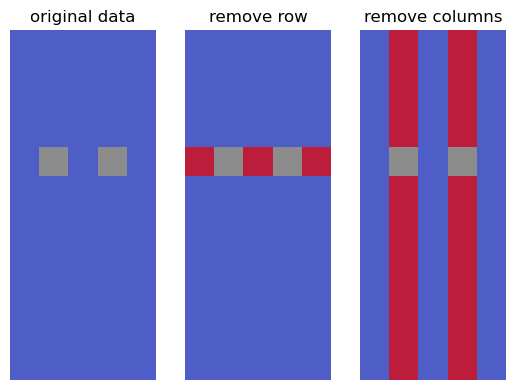

In [5]:
x = np.zeros((12, 5))
x[7, [1, 3]] = np.nan

plt.figure()
plt.subplot(1, 3, 1)
plot(x, show=False, title="original data")
plt.subplot(1, 3, 2)
plot(x, rows_to_remove=[7], show=False, title="remove row")
plt.subplot(1, 3, 3)
plot(x, cols_to_remove=[1, 3], show=False, title="remove columns")
plt.savefig('at_hand_two.png', bbox_inches='tight', dpi=DPI)
plt.show()

In [6]:
def heights(x, axis=0):
    return (x.shape[axis] - np.argmax(np.flip(x, axis=axis), axis=axis)).astype(np.uint32)

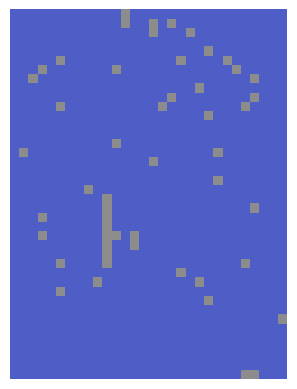

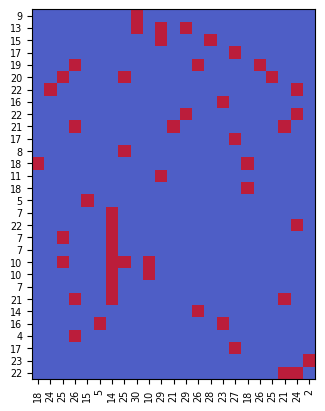

In [7]:
x = generate_mar(m=40, n=30, ratio=0.04)
x[12:19, 10] = np.nan

plot(x, show=False)
plt.savefig('algo_data.png', bbox_inches='tight', dpi=DPI)
plt.show()


nan_rows, nan_cols = np.isnan(x).nonzero()
nan_rows, nan_cols = np.unique(nan_rows), np.unique(nan_cols)
xp = np.isnan(x[nan_rows][:, nan_cols])
hx, hy = heights(xp, axis=0), heights(xp, axis=1)
plot(xp, xticks=hx, yticks=hy, show=False)
plt.savefig('algo_0.png', bbox_inches='tight', dpi=DPI)
plt.show()

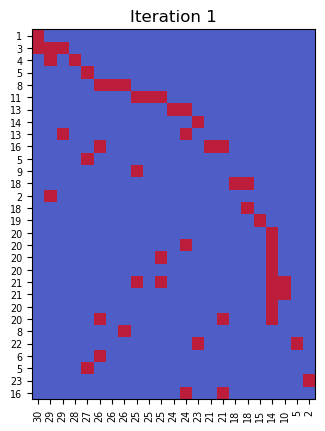

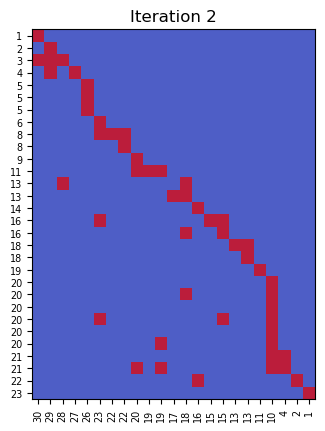

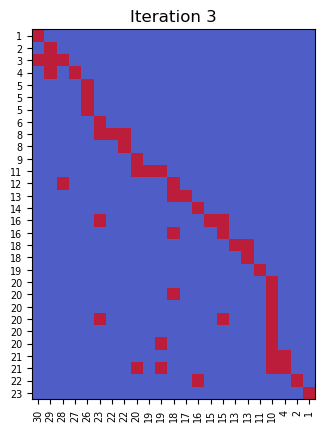

In [8]:
hx, hy = heights(xp, axis=0).astype(np.uint32), heights(xp, axis=1).astype(np.uint32)
k = 0
while not (OptiMask.is_decreasing(hx) and OptiMask.is_decreasing(hy)):
    axis = k % 2
    p_step = np.argsort(-heights(xp, axis=axis))
    if axis == 0:
        xp = xp[:, p_step]
    if axis == 1:
        xp = xp[p_step]
    hx, hy = heights(xp, axis=0).astype(np.uint32), heights(xp, axis=1).astype(
        np.uint32
    )
    plot(xp, xticks=hx, yticks=hy, title=f"Iteration {k+1}", show=False)
    plt.savefig(f'algo_{k+1}.png', bbox_inches='tight', dpi=DPI)
    plt.show()
    k += 1

In [9]:
rows, cols = OptiMask(n_tries=10000).solve(x)

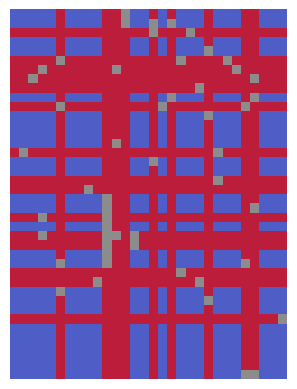

In [10]:
plot(x, rows, cols, show=False)
plt.savefig('algo_result.png', bbox_inches='tight', dpi=DPI)
plt.show()